# 05 - Arvore de Decisao

## Conceito
Uma arvore de decisao divide o espaco de features em regioes retangulares,
fazendo perguntas do tipo "feature X <= valor?". Cada no interno testa uma
feature, cada folha da uma previsao.

## Criterios de divisao
- Gini: impureza de Gini (padrao em classificacao)
- Entropy: ganho de informacao (id3, c4.5)
- MSE / MAE: para regressao

## Vantagens
- Interpretavel (da para visualizar e explicar)
- Nao precisa normalizar
- Lida com features numericas e categoricas
- Captura interacoes nao lineares

## Desvantagens
- Propensa a overfitting sem poda
- Instavel: pequenas mudancas nos dados mudam a arvore
- Fronteiras ortogonais (eixo-alinhadas)

## Controle de overfitting
- max_depth: profundidade maxima
- min_samples_split: minimo de amostras para dividir
- min_samples_leaf: minimo de amostras por folha
- max_features: features consideradas em cada split
- ccp_alpha: poda por complexidade de custo

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

iris = load_iris()
X, y = iris.data, iris.target # type: ignore

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Arvore sem limite de profundidade
modelo_livre = DecisionTreeClassifier(random_state=42)
modelo_livre.fit(X_train, y_train)

print("Acuracia treino:", round(accuracy_score(y_train, modelo_livre.predict(X_train)), 3))
print("Acuracia teste :", round(accuracy_score(y_test, modelo_livre.predict(X_test)), 3))
print("Profundidade   :", modelo_livre.get_depth())

Acuracia treino: 1.0
Acuracia teste : 0.933
Profundidade   : 5


## Overfitting

Sem poda, a arvore cresce ate memorizar o treino. A acuracia no treino
fica proxima de 1.0, mas a de teste nao acompanha.

In [2]:
# Variando a profundidade maxima
profundidades = [1, 2, 3, 4, 5, 7, 10, None]
for d in profundidades:
    modelo = DecisionTreeClassifier(max_depth=d, random_state=42)
    modelo.fit(X_train, y_train)
    ac_tr = accuracy_score(y_train, modelo.predict(X_train))
    ac_te = accuracy_score(y_test, modelo.predict(X_test))
    print(f"max_depth={str(d):<5} treino={ac_tr:.3f} teste={ac_te:.3f}")

max_depth=1     treino=0.667 teste=0.667
max_depth=2     treino=0.967 teste=0.933
max_depth=3     treino=0.983 teste=0.967
max_depth=4     treino=0.992 teste=0.933
max_depth=5     treino=1.000 teste=0.933
max_depth=7     treino=1.000 teste=0.933
max_depth=10    treino=1.000 teste=0.933
max_depth=None  treino=1.000 teste=0.933


In [ ]:
# Escolhendo profundidade por validacao cruzada
profundidades = range(1, 15)
medias = []

for d in profundidades:
    modelo = DecisionTreeClassifier(max_depth=d, random_state=42)
    scores = cross_val_score(modelo, X_train, y_train, cv=5)
    medias.append(scores.mean())

melhor_d = list(profundidades)[int(np.argmax(medias))]
print("Melhor profundidade (cv):", melhor_d)

plt.figure(figsize=(7, 4))
plt.plot(list(profundidades), medias, marker="o")
plt.axvline(melhor_d, color="red", linestyle="--", label=f"melhor = {melhor_d}")
plt.xlabel("max_depth")
plt.ylabel("acuracia media (cv)")
plt.title("Escolha da profundidade")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

## Visualizando a arvore

Com max_depth pequeno, da para visualizar e explicar as regras.

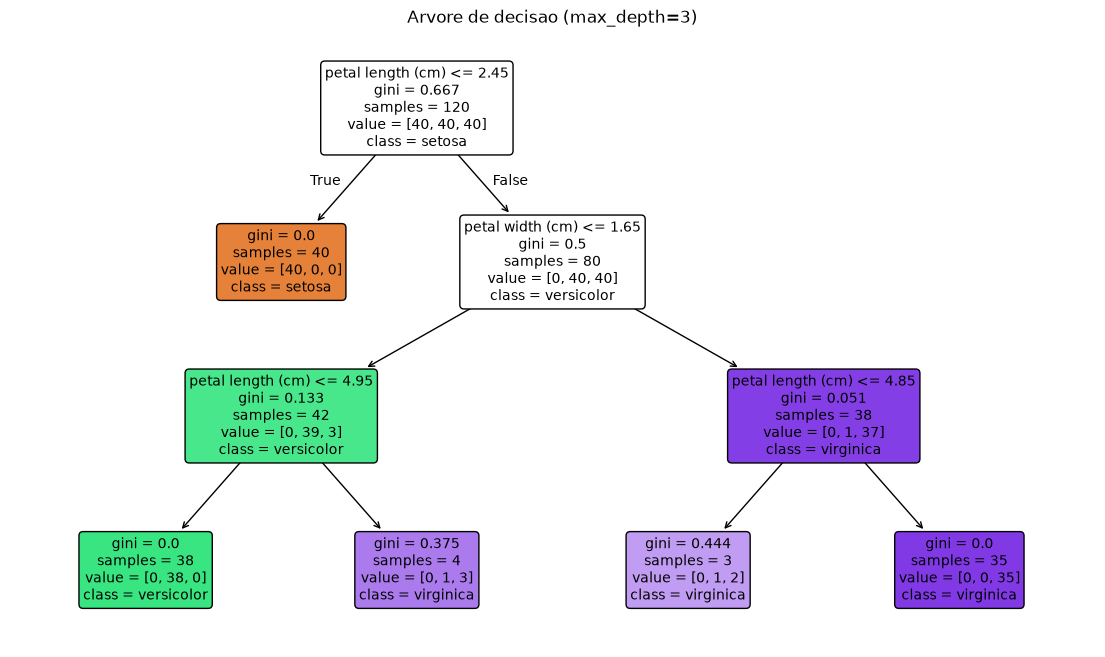

In [3]:
modelo = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo.fit(X_train, y_train)

plt.figure(figsize=(14, 8))
plot_tree(
    modelo,
    feature_names=iris.feature_names, # type: ignore
    class_names=iris.target_names, # type: ignore
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Arvore de decisao (max_depth=3)")
plt.show()

## Importancia das features

A importancia mede a reducao de impureza proporcionada por cada feature.
Nao indica direcao (positiva/negativa), apenas relevancia.

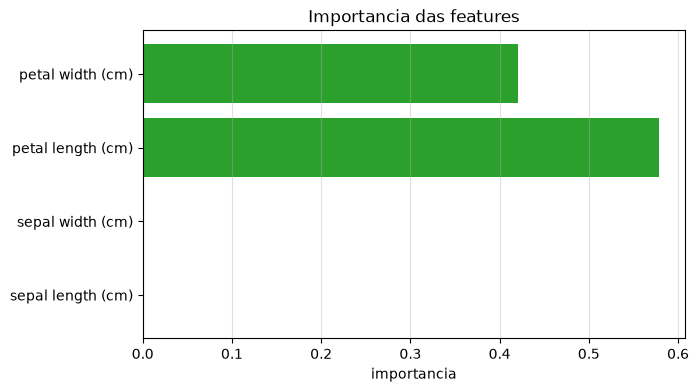

In [4]:
importancias = modelo.feature_importances_

plt.figure(figsize=(7, 4))
plt.barh(iris.feature_names, importancias, color="tab:green") # type: ignore
plt.xlabel("importancia")
plt.title("Importancia das features")
plt.grid(axis="x", alpha=0.4)
plt.show()

## Arvore de regressao

Para alvo continuo, a arvore preve a media das amostras em cada folha.

In [5]:
from sklearn.datasets import load_diabetes
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

dados = load_diabetes()
Xr, yr = dados.data, dados.target # type: ignore
X_tr, X_te, y_tr, y_te = train_test_split(Xr, yr, test_size=0.2, random_state=42)

for d in [2, 3, 5, None]:
    m = DecisionTreeRegressor(max_depth=d, random_state=42).fit(X_tr, y_tr)
    print(f"max_depth={str(d):<5} R2 treino={r2_score(y_tr, m.predict(X_tr)):.3f} "
          f"teste={r2_score(y_te, m.predict(X_te)):.3f}")

max_depth=2     R2 treino=0.447 teste=0.295
max_depth=3     R2 treino=0.517 teste=0.329
max_depth=5     R2 treino=0.669 teste=0.334
max_depth=None  R2 treino=1.000 teste=0.061


## Exercicios

1. Ajuste min_samples_leaf e veja o efeito na acuracia de teste.
2. Compare criterion="gini" e criterion="entropy".
3. Use ccp_alpha para podar uma arvore e compare com max_depth.
4. Explique por que arvores profundas memorizam o treino.